# Lab 4: EDA and Dataset Bias Assessment

## Part A) Environment and Dataset Setup

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

NAME = "Lorenzo Bela, Robert Callorina, Kean Guzon"
SECTION = "58036"
DATE = "03/15/2026"
DATASET_NAME = "Relief Goods"

print("Name:", NAME)
print("Section:", SECTION)
print("Date:", DATE)
print("Dataset name:", DATASET_NAME)

DATA_DIR = Path("../data")
OUT_FIG = Path("../outputs/figures")
OUT_TBL = Path("../outputs/tables")
OUT_LOG = Path("../outputs/logs")

for p in [OUT_FIG, OUT_TBL, OUT_LOG]:
    p.mkdir(parents=True, exist_ok=True)

Name: Lorenzo Bela, Robert Callorina, Kean Guzon
Section: 58036
Date: 03/15/2026
Dataset name: Relief Goods


## Part B) Load Dataset

In [ ]:
valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
class_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
class_names = [d.name for d in class_dirs]

all_images = []
all_labels = []
target_size = None
resized_count = 0

for class_idx, class_dir in enumerate(class_dirs):
    images_dir = class_dir / "images"
    if not images_dir.is_dir():
        continue

    for p in sorted(images_dir.iterdir()):
        if p.is_file() and p.suffix.lower() in valid_ext:
            img = Image.open(p).convert("RGB")
            if target_size is None:
                target_size = img.size
            elif img.size != target_size:
                img = img.resize(target_size)
                resized_count += 1

            all_images.append(np.array(img))
            all_labels.append(class_idx)

images = np.stack(all_images, axis=0)
labels = np.array(all_labels, dtype=np.int64)
dropped_count = 0

print("Total samples:", len(images))
print("Class names:", class_names)
print("Image shape:", images[0].shape)
print("Resized images:", resized_count)
print("Data type:", images.dtype)

Total samples: 250
Class names: ['bottled water', 'canned goods', 'combo', 'Noodles', 'Rice']
Image shape: (640, 480, 3)
Resized images: 146
Data type: uint8


## Part C) Structural Dataset Analysis

In [4]:
subset_n = min(200, len(images))
subset = images[:subset_n]

channels = subset.shape[-1]
pixel_min = int(subset.min())
pixel_max = int(subset.max())

lines = []
lines.append("Lab 04 - Structural Dataset Analysis\n")
lines.append(f"Checked samples: {subset_n}\n")
lines.append(f"Image shape: {subset[0].shape}\n")
lines.append(f"Channels: {channels}\n")
lines.append(f"Pixel value range: [{pixel_min}, {pixel_max}]\n")
lines.append(f"Dropped due to shape mismatch: {dropped_count}\n")

log_path = OUT_LOG / "lab04_structure_check.txt"
log_path.write_text("".join(lines), encoding="utf-8")

print("".join(lines))
print("Saved:", log_path)

Lab 04 - Structural Dataset Analysis
Checked samples: 200
Image shape: (640, 480, 3)
Channels: 3
Pixel value range: [0, 255]
Dropped due to shape mismatch: 0

Saved: ..\outputs\logs\lab04_structure_check.txt


## Part D) Class Distribution Analysis

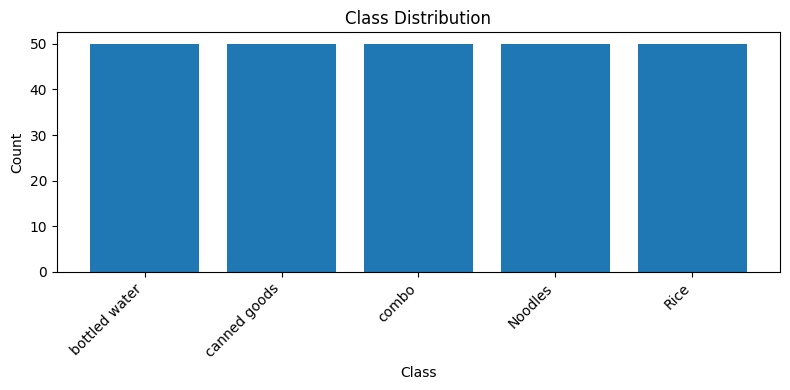

,class_index,class_name,count
0,0,bottled water,50
1,1,canned goods,50
2,2,combo,50
3,3,Noodles,50
4,4,Rice,50


Saved: ..\outputs\tables\lab04_class_distribution.csv
Saved: ..\outputs\figures\lab04_class_distribution.png


In [5]:
counts = pd.Series(labels).value_counts().sort_index()

df = pd.DataFrame({
    "class_index": counts.index,
    "class_name": [class_names[i] for i in counts.index],
    "count": counts.values
})

csv_path = OUT_TBL / "lab04_class_distribution.csv"
df.to_csv(csv_path, index=False)

plt.figure(figsize=(8, 4))
plt.bar(df["class_name"], df["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()

fig_path = OUT_FIG / "lab04_class_distribution.png"
plt.savefig(fig_path, dpi=150)
plt.show()

display(df)
print("Saved:", csv_path)
print("Saved:", fig_path)

## Part E) Visual Pattern Inspection

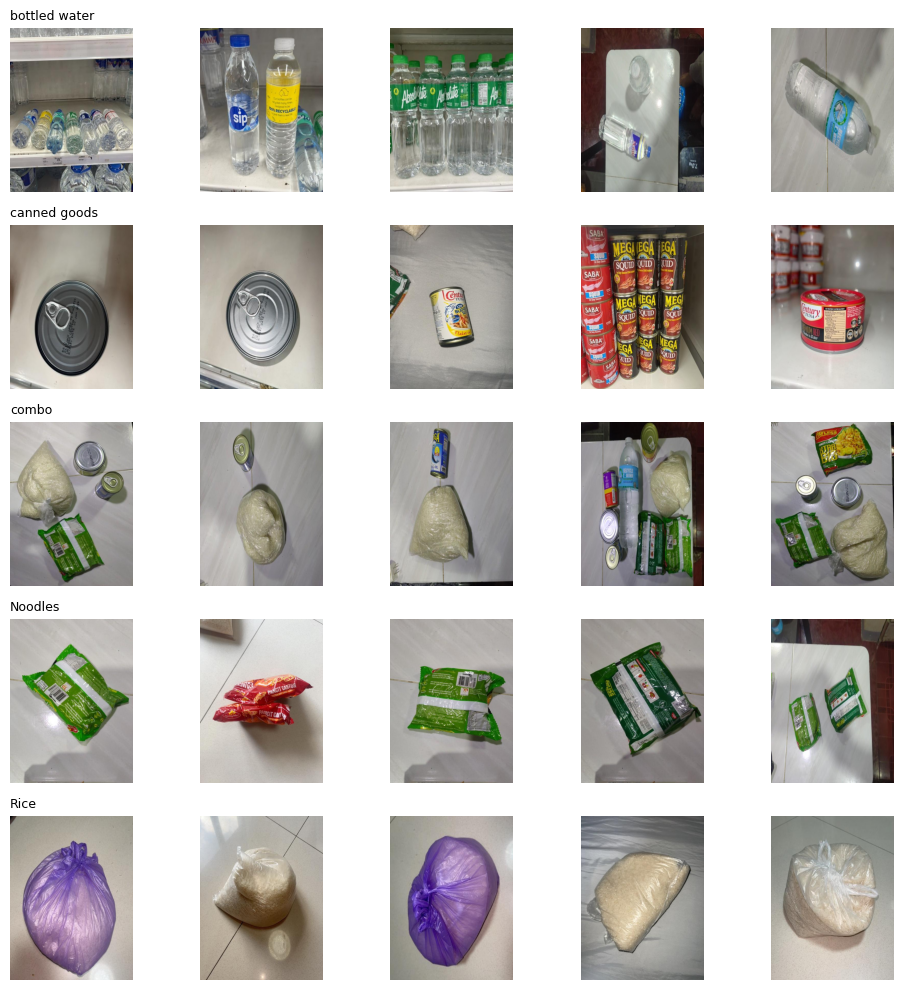

Saved: ..\outputs\figures\lab04_class_samples.png


In [6]:
rows = len(class_names)
cols = 5
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

if rows == 1:
    axes = np.array([axes])

for i in range(rows):
    idx = np.where(labels == i)[0]
    pick_n = min(cols, len(idx))
    chosen = np.random.choice(idx, size=pick_n, replace=False) if pick_n > 0 else []

    for j in range(cols):
        ax = axes[i, j]
        ax.axis("off")
        if j < pick_n:
            ax.imshow(images[chosen[j]])
        if j == 0:
            ax.set_title(class_names[i], loc="left", fontsize=9)

plt.tight_layout()
fig_path = OUT_FIG / "lab04_class_samples.png"
plt.savefig(fig_path, dpi=150)
plt.show()

print("Saved:", fig_path)

## Part F) Pixel-Level Statistical Analysis

Mean (R,G,B): [0.21845333 0.21845333 0.21845333]
Std  (R,G,B): [0.33301064 0.3316616  0.3258138 ]


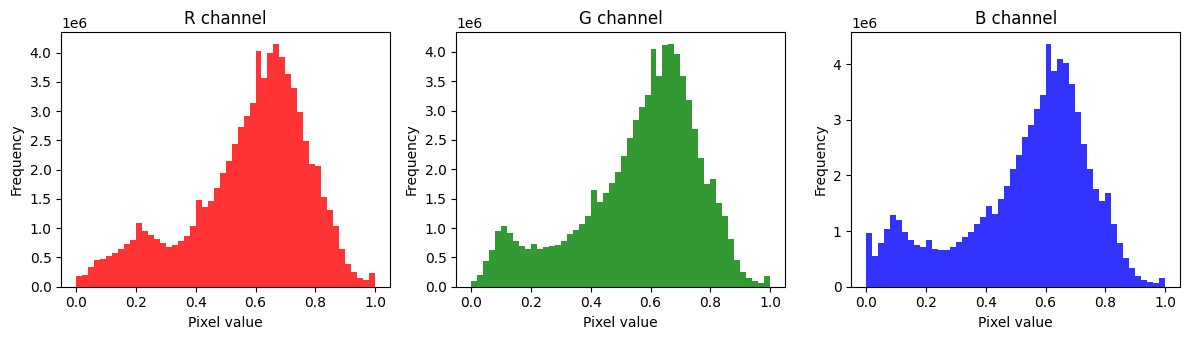

Saved: ..\outputs\figures\lab04_pixel_histograms.png


In [7]:
x = images.astype(np.float32) / 255.0
mean_rgb = x.mean(axis=(0, 1, 2))
std_rgb = x.std(axis=(0, 1, 2))

print("Mean (R,G,B):", mean_rgb)
print("Std  (R,G,B):", std_rgb)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
colors = ["red", "green", "blue"]
labels_ch = ["R", "G", "B"]

for i in range(3):
    axes[i].hist(x[..., i].ravel(), bins=50, color=colors[i], alpha=0.8)
    axes[i].set_title(f"{labels_ch[i]} channel")
    axes[i].set_xlabel("Pixel value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
fig_path = OUT_FIG / "lab04_pixel_histograms.png"
plt.savefig(fig_path, dpi=150)
plt.show()

print("Saved:", fig_path)

## Part G) Bias Identification and Interpretation

In [8]:
counts = pd.Series(labels).value_counts()
max_count = int(counts.max())
min_count = int(counts.min())
ratio = (max_count / min_count) if min_count > 0 else float("inf")

bias_text = []
bias_text.append("Lab 04 - Bias Identification and Interpretation\n\n")

bias_text.append("Bias 1: Class imbalance bias\n")
bias_text.append(f"Cause: Class counts vary (max/min ratio = {ratio:.2f}).\n")
bias_text.append("Impact: Model may favor majority classes and miss minority classes.\n")
bias_text.append("Mitigation: Use class weights or balanced sampling.\n\n")

bias_text.append("Bias 2: Background/context bias\n")
bias_text.append("Cause: Images in a class can share similar backgrounds or capture settings.\n")
bias_text.append("Impact: Model may learn context cues instead of object features.\n")
bias_text.append("Mitigation: Use stronger augmentation and collect more varied backgrounds.\n")

log_path = OUT_LOG / "lab04_bias_analysis.txt"
log_path.write_text("".join(bias_text), encoding="utf-8")

print("".join(bias_text))
print("Saved:", log_path)

Lab 04 - Bias Identification and Interpretation

Bias 1: Class imbalance bias
Cause: Class counts vary (max/min ratio = 1.00).
Impact: Model may favor majority classes and miss minority classes.
Mitigation: Use class weights or balanced sampling.

Bias 2: Background/context bias
Cause: Images in a class can share similar backgrounds or capture settings.
Impact: Model may learn context cues instead of object features.
Mitigation: Use stronger augmentation and collect more varied backgrounds.

Saved: ..\outputs\logs\lab04_bias_analysis.txt
